In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

In [2]:
dataset_path = "Dataset"

In [3]:
data = []
labels = []

IMG_SIZE = 64

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    for subfolder in os.listdir(category_path):
        subfolder_path = os.path.join(category_path, subfolder)

        for img_name in os.listdir(subfolder_path):
            img_path = os.path.join(subfolder_path, img_name)

            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img.flatten()  # flatten for XGBoost

                data.append(img)
                labels.append(category)

            except:
                pass

print("Total Images:", len(data))

Total Images: 18633


In [4]:
X = np.array(data)
y = np.array(labels)

print("Feature Shape:", X.shape)

Feature Shape: (18633, 12288)


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Fresh Vegitable' 'Rotten Vegitable']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [7]:


model = XGBClassifier(
    n_estimators=100,       
    max_depth=4,             
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',     
    n_jobs=-1,               
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [8]:
y_pred = model.predict(X_test)

Accuracy: 0.8620874698148645

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2653
           1       0.81      0.68      0.74      1074

    accuracy                           0.86      3727
   macro avg       0.85      0.81      0.82      3727
weighted avg       0.86      0.86      0.86      3727



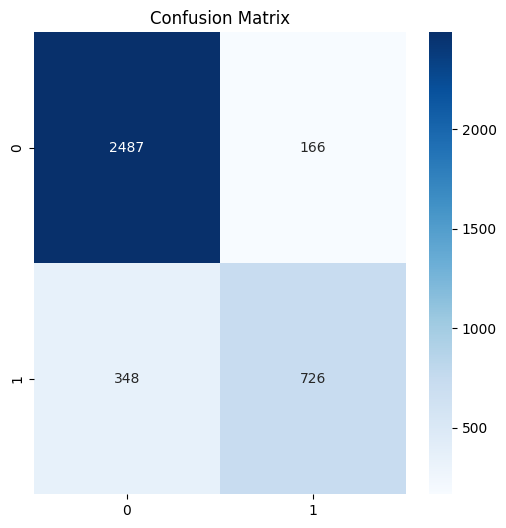

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()